# Random Forest: Gains from Environment Inputs

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    classification_report,
)

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

# Path
csv_path = "one_trial_5_agents_agent_steps.csv"

# Plot defaults
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300

## Load Data and Prepare Features

In [17]:
df = pd.read_csv(csv_path)

feature_cols = [
    "speed",
    "acceleration_magnitude",
    "field_delta",
    "neighbor_count",
    "nearest_neighbor_distance",
    "mean_neighbor_distance",
]

output_cols = [
    "avoidance_gain",
    "quark_gain",
    "directional_derivative_gain",
    "linear_drag_gain",
]

cols = feature_cols + output_cols
missing = [c for c in cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

clean = df[cols].dropna().reset_index(drop=True)

X = clean[feature_cols]
print("rows:", len(clean))
print("features:", feature_cols)
print("outputs:", output_cols)

rows: 7280
features: ['speed', 'acceleration_magnitude', 'field_delta', 'neighbor_count', 'nearest_neighbor_distance', 'mean_neighbor_distance']
outputs: ['avoidance_gain', 'quark_gain', 'directional_derivative_gain', 'linear_drag_gain']


## Train/Test Split

In [18]:
X_train, X_test, idx_train, idx_test = train_test_split(
    X,
    np.arange(len(clean)),
    test_size=0.25,
    random_state=42,
)

df_train = clean.iloc[idx_train].reset_index(drop=True)
df_test = clean.iloc[idx_test].reset_index(drop=True)

print("train rows:", len(df_train), "test rows:", len(df_test))

train rows: 5460 test rows: 1820


## Quantile Binning for Classification Targets

In [19]:
def make_quantile_labels(series, q=3):
    """Bin series into quantiles. Returns labels and display names."""
    binned = pd.qcut(series, q=q, duplicates="drop")
    labels = binned.cat.codes
    label_names = [str(iv) for iv in binned.cat.categories]
    return labels, label_names


label_maps = {}
n_classes_map = {}

y_train_dict = {}
y_test_dict = {}

for col in output_cols:
    y_all, names = make_quantile_labels(clean[col], q=3)
    label_maps[col] = names
    n_classes_map[col] = len(names)
    y_train_dict[col] = y_all.iloc[idx_train].reset_index(drop=True)
    y_test_dict[col] = y_all.iloc[idx_test].reset_index(drop=True)

print("class bins per output:")
for col, names in label_maps.items():
    n = n_classes_map[col]
    print(f"  {col}: {n} classes -> {names}")


class bins per output:
  avoidance_gain: 1 classes -> ['(1.999, 8.0]']
  quark_gain: 1 classes -> ['(0.611, 8.0]']
  directional_derivative_gain: 3 classes -> ['(0.45, 2.084]', '(2.084, 3.57]', '(3.57, 8.0]']
  linear_drag_gain: 1 classes -> ['(0.049, 0.245]']


## Train Random Forests and Evaluate

/Users/motokinakajima/miniconda3/envs/hayabusa/lib/python3.11/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/motokinakajima/miniconda3/envs/hayabusa/lib/python3.11/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/motokinakajima/miniconda3/envs/hayabusa/lib/python3.11/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/motokinakajima/miniconda3/envs/hayabusa/lib/python3.11/site-packages/sklearn/metrics/_c


Classification report: avoidance_gain (1 classes)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1820

    accuracy                           1.00      1820
   macro avg       1.00      1.00      1.00      1820
weighted avg       1.00      1.00      1.00      1820


Classification report: quark_gain (1 classes)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1820

    accuracy                           1.00      1820
   macro avg       1.00      1.00      1.00      1820
weighted avg       1.00      1.00      1.00      1820


Classification report: directional_derivative_gain (3 classes)
              precision    recall  f1-score   support

           0       0.65      0.71      0.68       590
           1       0.61      0.69      0.65       604
           2       0.85      0.67      0.75       626

    accuracy                           0.69      1820
   macro avg       0

/Users/motokinakajima/miniconda3/envs/hayabusa/lib/python3.11/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/motokinakajima/miniconda3/envs/hayabusa/lib/python3.11/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


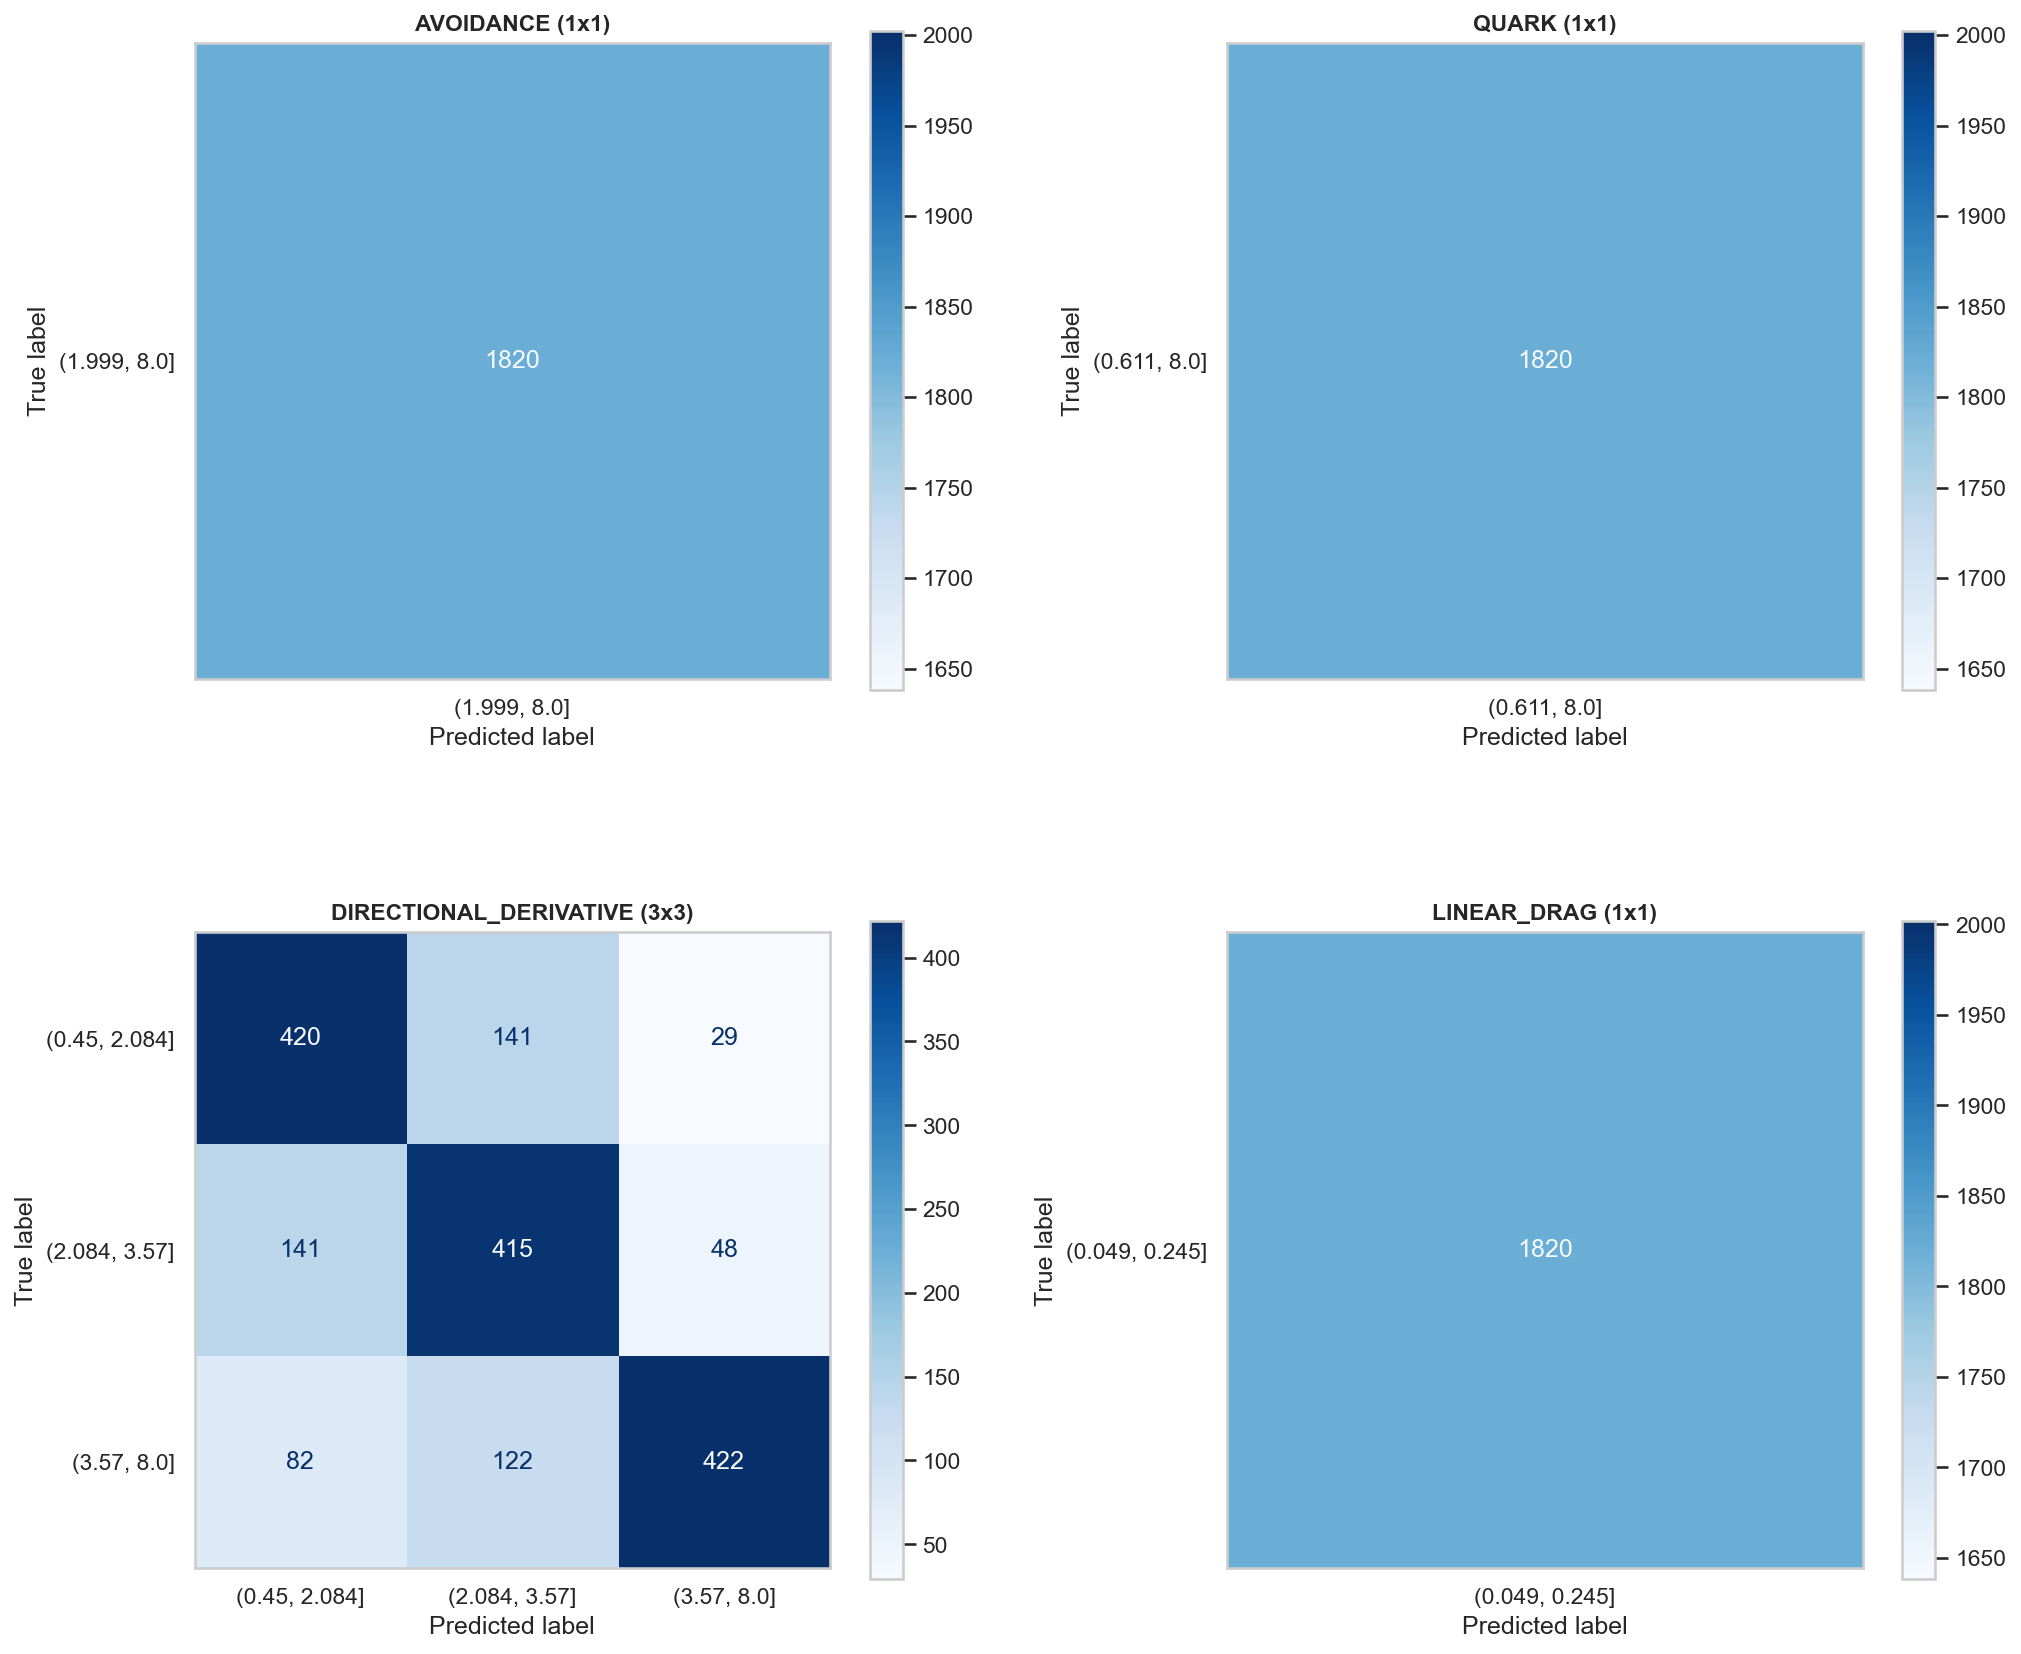


OVERALL RESULTS
                        classes  accuracy  balanced_accuracy  f1_macro  f1_weighted  precision  recall    rmse
gain                                                                                                          
avoidance                     1    1.0000              1.000     1.000       1.0000     1.0000   1.000  0.0000
quark                         1    1.0000              1.000     1.000       1.0000     1.0000   1.000  0.0000
directional_derivative        3    0.6907              0.691     0.693       0.6938     0.7037   0.691  0.7016
linear_drag                   1    1.0000              1.000     1.000       1.0000     1.0000   1.000  0.0000


In [21]:
from sklearn.metrics import mean_squared_error

results = []
cms_data = []

for col in output_cols:
    y_train = y_train_dict[col]
    y_test = y_test_dict[col]
    n_classes = n_classes_map[col]

    clf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )
    clf.fit(df_train[feature_cols], y_train)
    y_pred = clf.predict(df_test[feature_cols])

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "gain": col.replace("_gain", ""),
        "classes": n_classes,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision": prec_macro,
        "recall": rec_macro,
        "rmse": rmse,
    })

    # Store confusion matrix data for grouped visualization
    cm = confusion_matrix(y_test, y_pred)
    cms_data.append({
        "col": col,
        "cm": cm,
        "labels": label_maps[col],
        "n_classes": n_classes,
    })

    print(f"\n{'='*60}")
    print(f"Classification report: {col} ({n_classes} classes)")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, zero_division=0))

# Display all confusion matrices in 2x2 grid with proper spacing
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, data in enumerate(cms_data):
    ax = axes[idx]
    disp = ConfusionMatrixDisplay(data["cm"], display_labels=data["labels"])
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.grid(False)  # Remove grid lines
    ax.set_title(f"{data['col'].replace('_gain', '').upper()} ({data['n_classes']}x{data['n_classes']})", 
                 fontsize=11, fontweight="bold")

fig.subplots_adjust(left=0.08, right=0.95, top=0.94, bottom=0.08, hspace=0.35, wspace=0.3)
plt.show()

# Display results table
result_df = pd.DataFrame(results).set_index("gain")
print("\n" + "="*80)
print("OVERALL RESULTS")
print("="*80)
print(result_df.round(4).to_string())